In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("../data/processed/epiclim_preprocessed.csv")
df['year_month'] = pd.to_datetime(df['year_month'])
print("Shape:", df.shape)
print(df.dtypes)


Shape: (6709, 15)
state_ut                    object
district                    object
year_month          datetime64[ns]
Latitude                   float64
Longitude                  float64
Month                        int64
Season                      object
Cases                      float64
Deaths                     float64
preci                      float64
LAI                        float64
Temp                       float64
Cases_MA_3                 float64
Deaths_MA_3                float64
Case_Growth_Rate           float64
dtype: object


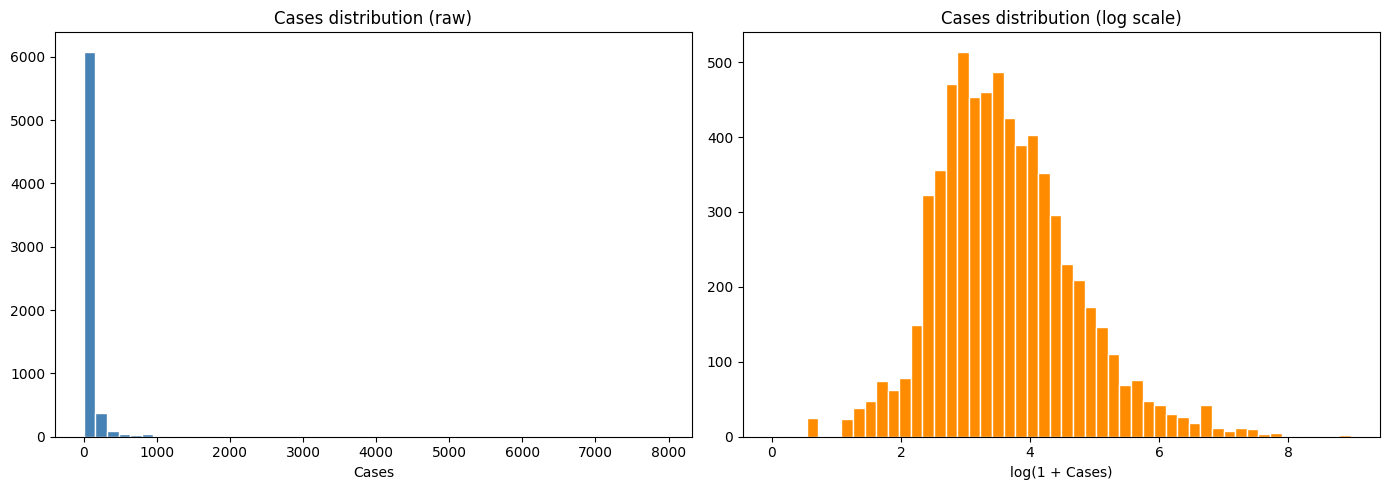

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Cases'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Cases distribution (raw)')
axes[0].set_xlabel('Cases')
axes[1].hist(np.log1p(df['Cases']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Cases distribution (log scale)')
axes[1].set_xlabel('log(1 + Cases)')
plt.tight_layout()
plt.savefig("../outputs/cases_distribution.png", dpi=150)
plt.show()


Top 10 districts by total cases:
 district
North 24 Parganas    22429.92
New Delhi            11483.72
Nadia                 9331.12
Hooghly               9218.80
East Siang            8795.48
Paschim Medinipur     7483.36
Bankura               6411.00
South 24 Parganas     6348.12
Birbhum               5480.00
East Singhbhum        5361.24
Name: Cases, dtype: float64


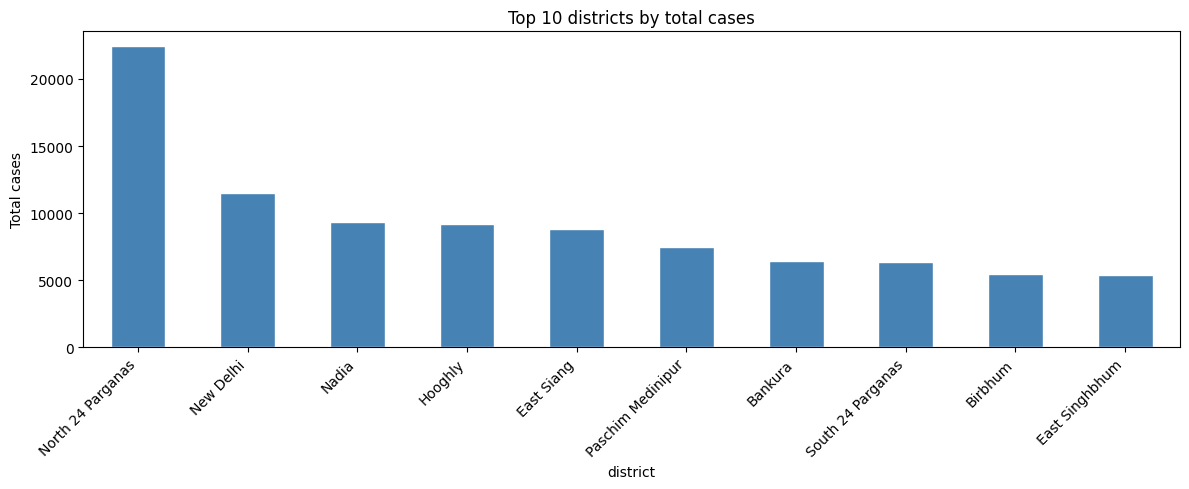

In [15]:
top_districts = (
    df.groupby('district')['Cases']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop 10 districts by total cases:\n", top_districts)

plt.figure(figsize=(12, 5))
top_districts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 districts by total cases')
plt.ylabel('Total cases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../outputs/top10_districts.png", dpi=150)
plt.show()


Cases by season:
 Season
Monsoon         317735.08
Summer          101897.72
Post-Monsoon     74700.48
Winter           42232.12
Name: Cases, dtype: float64


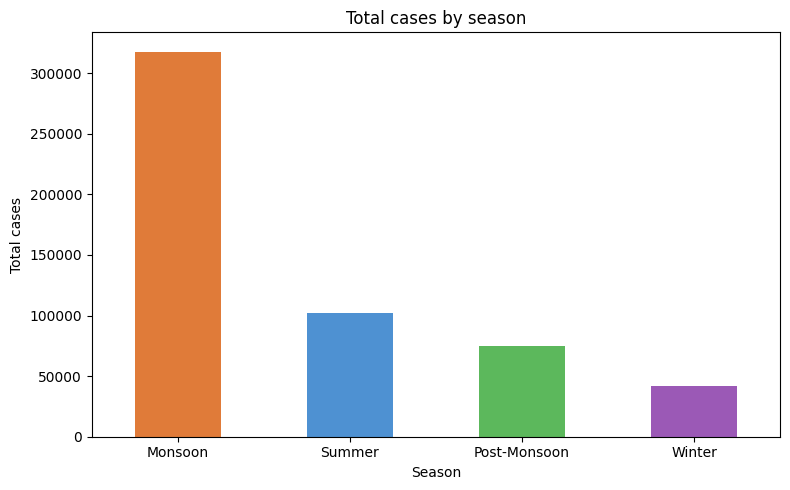

In [16]:
season_stats = df.groupby('Season')['Cases'].sum().sort_values(ascending=False)
print("\nCases by season:\n", season_stats)

plt.figure(figsize=(8, 5))
season_stats.plot(kind='bar', color=['#e07b39','#4e91d2','#5cb85c','#9b59b6'])
plt.title('Total cases by season')
plt.ylabel('Total cases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/cases_by_season.png", dpi=150)
plt.show()

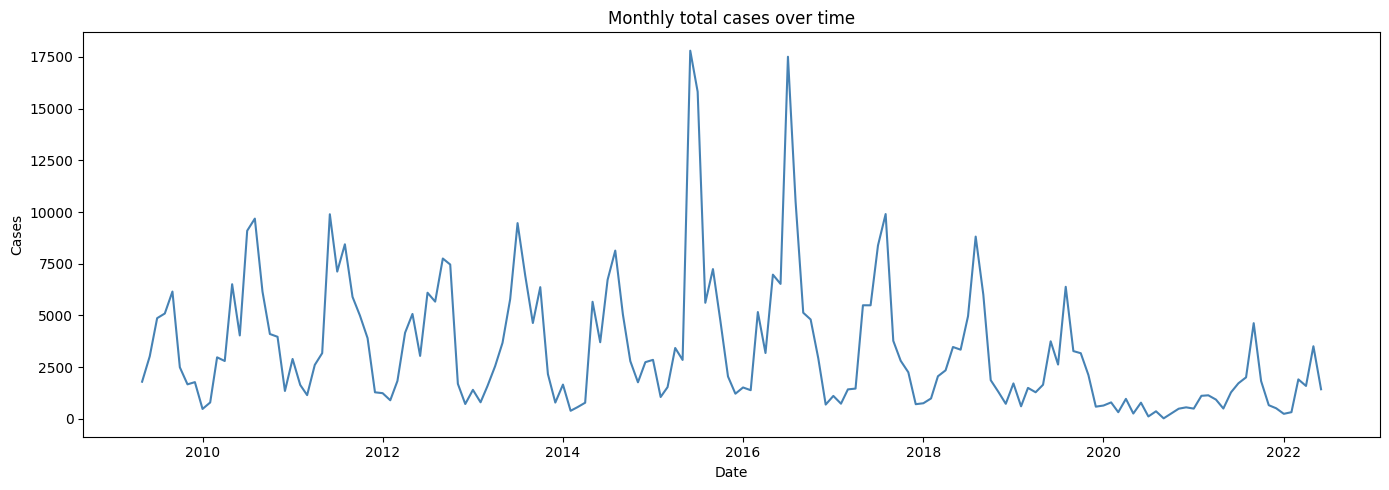

In [17]:
monthly = df.groupby('year_month')['Cases'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly['year_month'], monthly['Cases'], color='steelblue', linewidth=1.5)
plt.title('Monthly total cases over time')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.tight_layout()
plt.savefig("../outputs/monthly_trend.png", dpi=150)
plt.show()


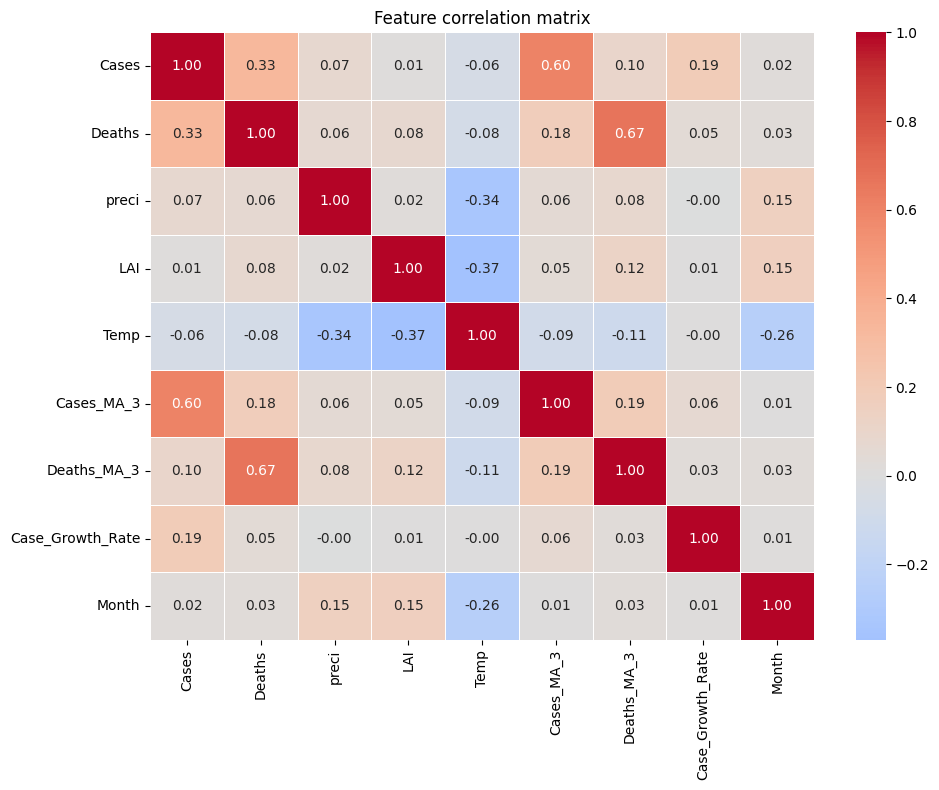

In [18]:
num_cols = ['Cases', 'Deaths', 'preci', 'LAI', 'Temp',
            'Cases_MA_3', 'Deaths_MA_3', 'Case_Growth_Rate', 'Month']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150)
plt.show()

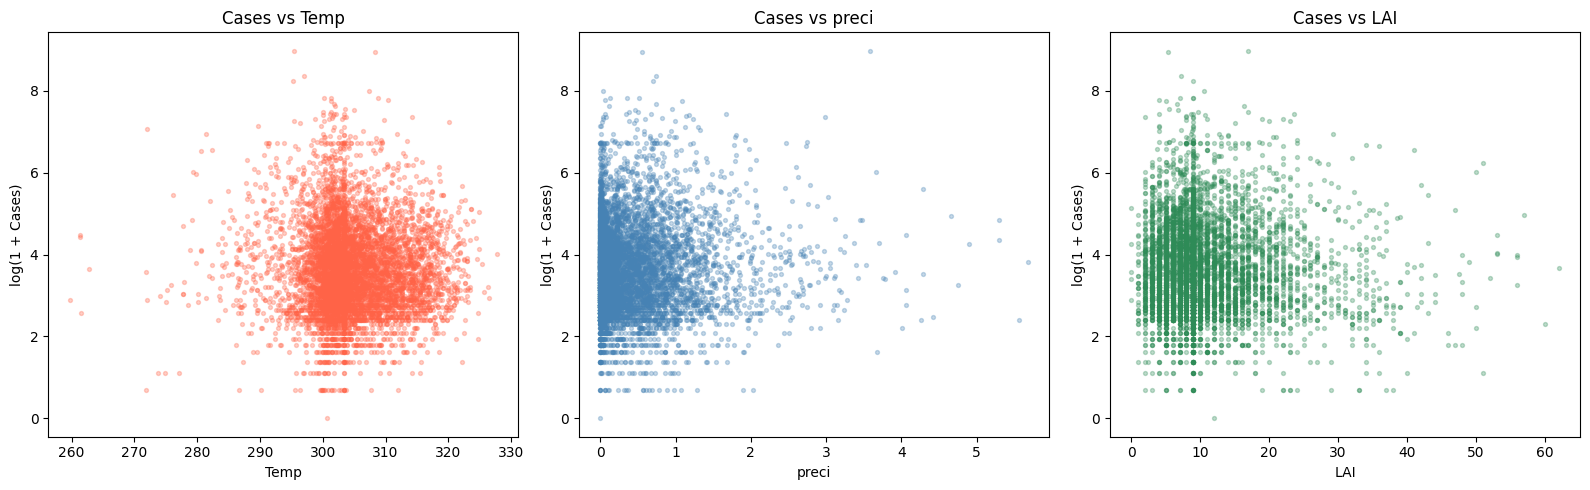


EDA complete — plots saved to ../outputs/


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat, color in zip(axes, ['Temp', 'preci', 'LAI'],
                           ['tomato', 'steelblue', 'seagreen']):
    ax.scatter(df[feat], np.log1p(df['Cases']), alpha=0.3, s=8, color=color)
    ax.set_xlabel(feat)
    ax.set_ylabel('log(1 + Cases)')
    ax.set_title(f'Cases vs {feat}')
plt.tight_layout()
plt.savefig("../outputs/cases_vs_climate.png", dpi=150)
plt.show()

print("\nEDA complete — plots saved to ../outputs/")